# Clustering Spotify Songs for Playlist Generation

In [94]:
## Loading Libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score

import collections
import joblib

### Loading the Dataset

In [26]:

df=pd.read_csv(r"C:\Users\ADMIN\Documents\AFRICDSA\Machine Learning\Spotify\spotify.csv")

In [27]:
pd.set_option("display.max_columns",None)

In [28]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [29]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

# Data Preprocessing

In [31]:
## Checking for missing values
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [32]:
# dropping null values
df.dropna(inplace=True)

In [33]:
# Dropping the unamed column
df=df.drop('Unnamed: 0',axis=1)

In [34]:
# Cheking for the duplicates
df.duplicated().sum()

450

In [35]:
# Dropping the duplicates
df.drop_duplicates(inplace=True)

In [36]:
# Doing a quick statistical analysis on our dataset features
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113549.000000,1.135490e+05,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000
mean,33.324433,2.280814e+05,0.567031,0.642091,5.309452,-8.243408,0.637866,0.084674,0.314064,0.155703,0.213613,0.474205,122.175745,3.904218
std,22.283855,1.064131e+05,0.173409,0.251053,3.560147,5.011422,0.480620,0.105762,0.331906,0.309217,0.190462,0.259204,29.972954,0.432117
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741840e+05,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296000,4.000000
50%,35.000000,2.130000e+05,0.580000,0.685000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615880e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048700,0.273000,0.683000,140.074000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [37]:
# Observing our features Datatypes 
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113549 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113549 non-null  int64  
 5   duration_ms       113549 non-null  int64  
 6   explicit          113549 non-null  bool   
 7   danceability      113549 non-null  float64
 8   energy            113549 non-null  float64
 9   key               113549 non-null  int64  
 10  loudness          113549 non-null  float64
 11  mode              113549 non-null  int64  
 12  speechiness       113549 non-null  float64
 13  acousticness      113549 non-null  float64
 14  instrumentalness  113549 non-null  float64
 15  liveness          113549 non-null  float64
 16  valence           113549 

In [38]:
# Dropping the Categorical features that are irrelevant when it comes to song clustering
data=df.drop((df.select_dtypes(include='object').columns),axis=1)
data

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [39]:
# encoding the Explicit Features with numeric binary values of 1 and 0 using the labelEncoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['explicit']=le.fit_transform(data['explicit'])

In [40]:
data

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,0,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,22,385000,0,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,22,271466,0,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,41,283893,0,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


## Exploratory Data Analysis

<Axes: xlabel='danceability', ylabel='Count'>

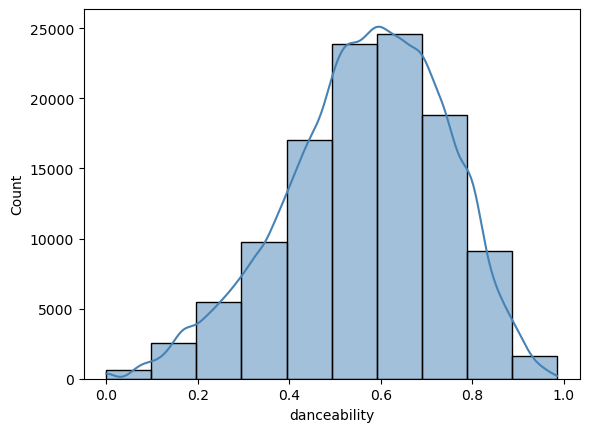

In [118]:
sns.histplot(data=data,x='danceability',kde=True, bins=10, color='steelblue')

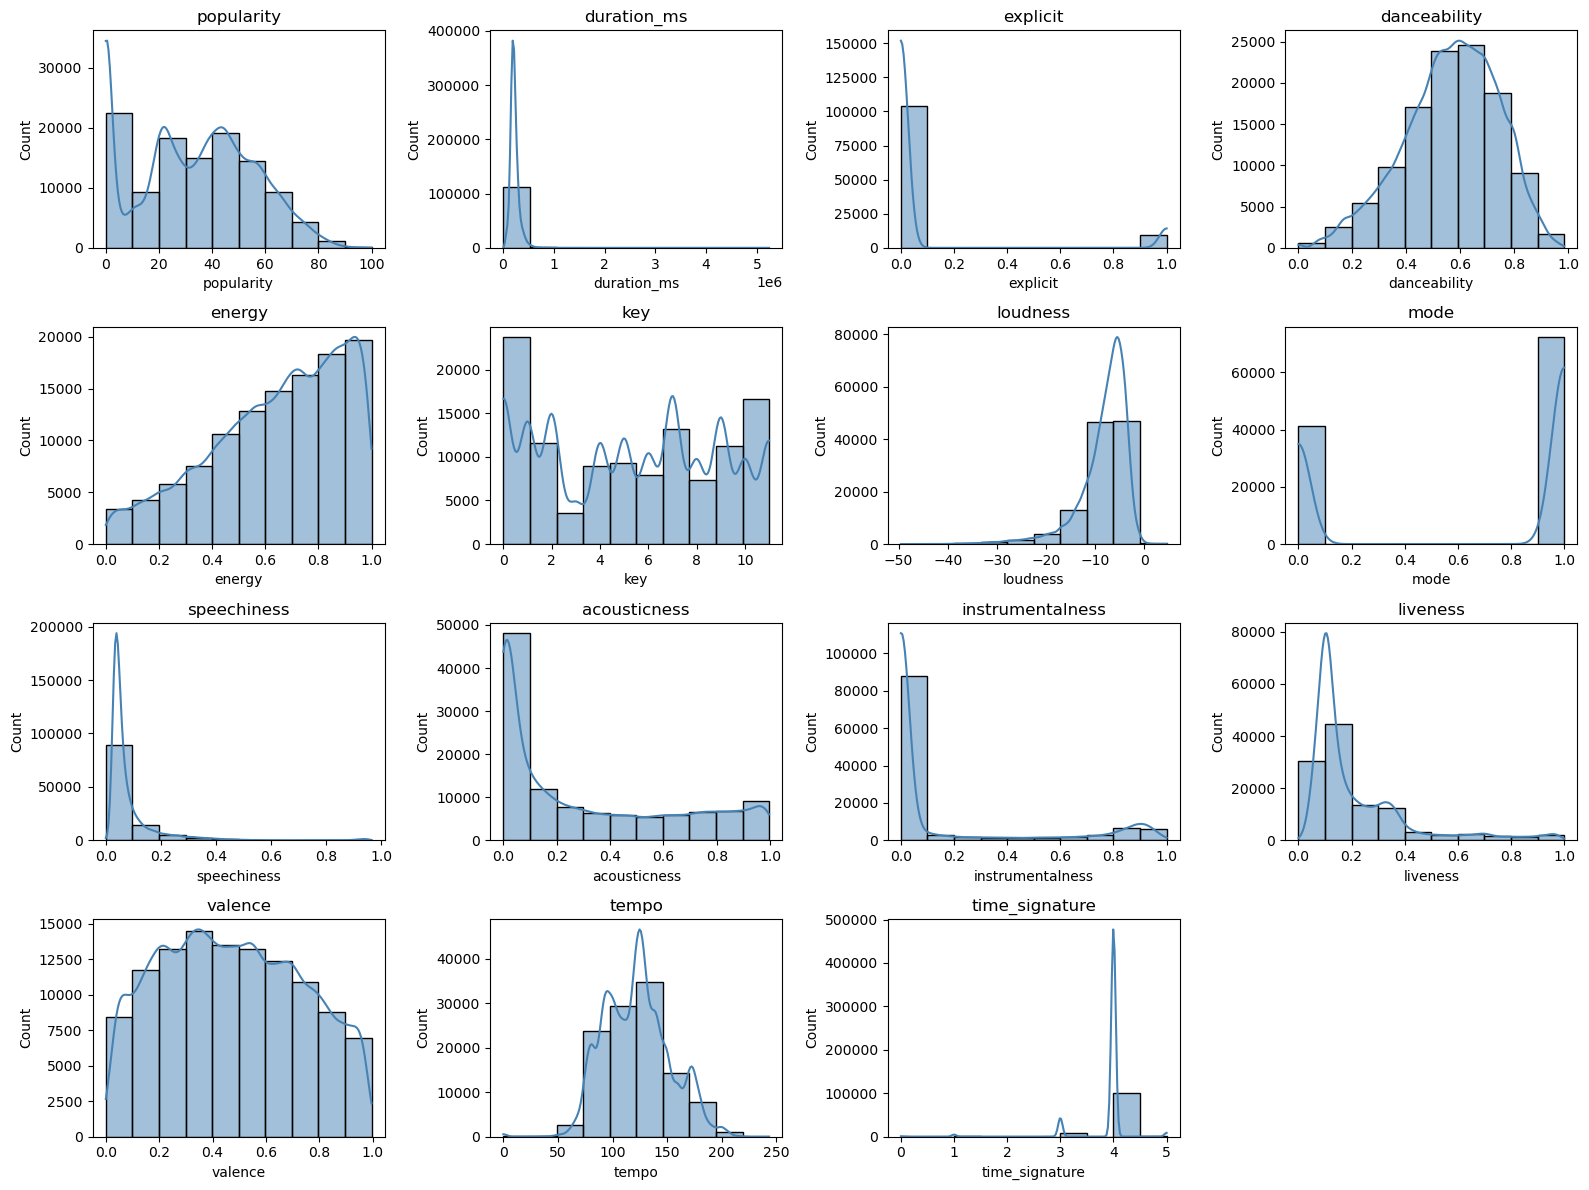

In [42]:
# Feature analysis
numeric_cols=data.columns
plt.figure(figsize=(16,12))
for i, col in enumerate(numeric_cols):
    plt.subplot(4,4,i+1)
    sns.histplot (data[col], kde=True, bins=10, color='steelblue')
    plt.title(col)

plt.tight_layout()
plt.show()

### Spotify Songs Feature Analysis (for Clustering)

- **High variation in `danceability`, `energy`, `valence`, and `loudness`**  
  These features show significant diversity across songs, making them ideal for clustering based on mood, style, or vibe.

- **Skewed features: `instrumentalness`, `acousticness`, `speechiness`, `liveness`**  
  These are heavily skewed toward 0, indicating most tracks are studio-produced with little acoustic or spoken content.

- **`duration_ms`**  
  Most songs are under 1 million ms (~17 minutes), with a few much longer ones — likely distinguishing typical songs from podcasts or sermons.

- **`explicit`**  
  The majority of songs are non-explicit (`0`), with a smaller portion marked as explicit (`1`).

- **`mode`**  
  Mostly skewed toward 1 (major key), suggesting that most songs are composed in a major scale.


In [44]:
#Unique genres
len(df['track_genre'].unique())

114

In [45]:
pd.set_option("display.max_rows",None)

### Outlier Detection 

<Axes: ylabel='duration_ms'>

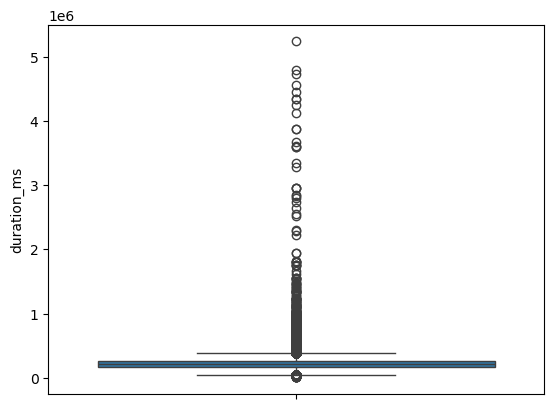

In [120]:
sns.boxplot(data=data,y='duration_ms')

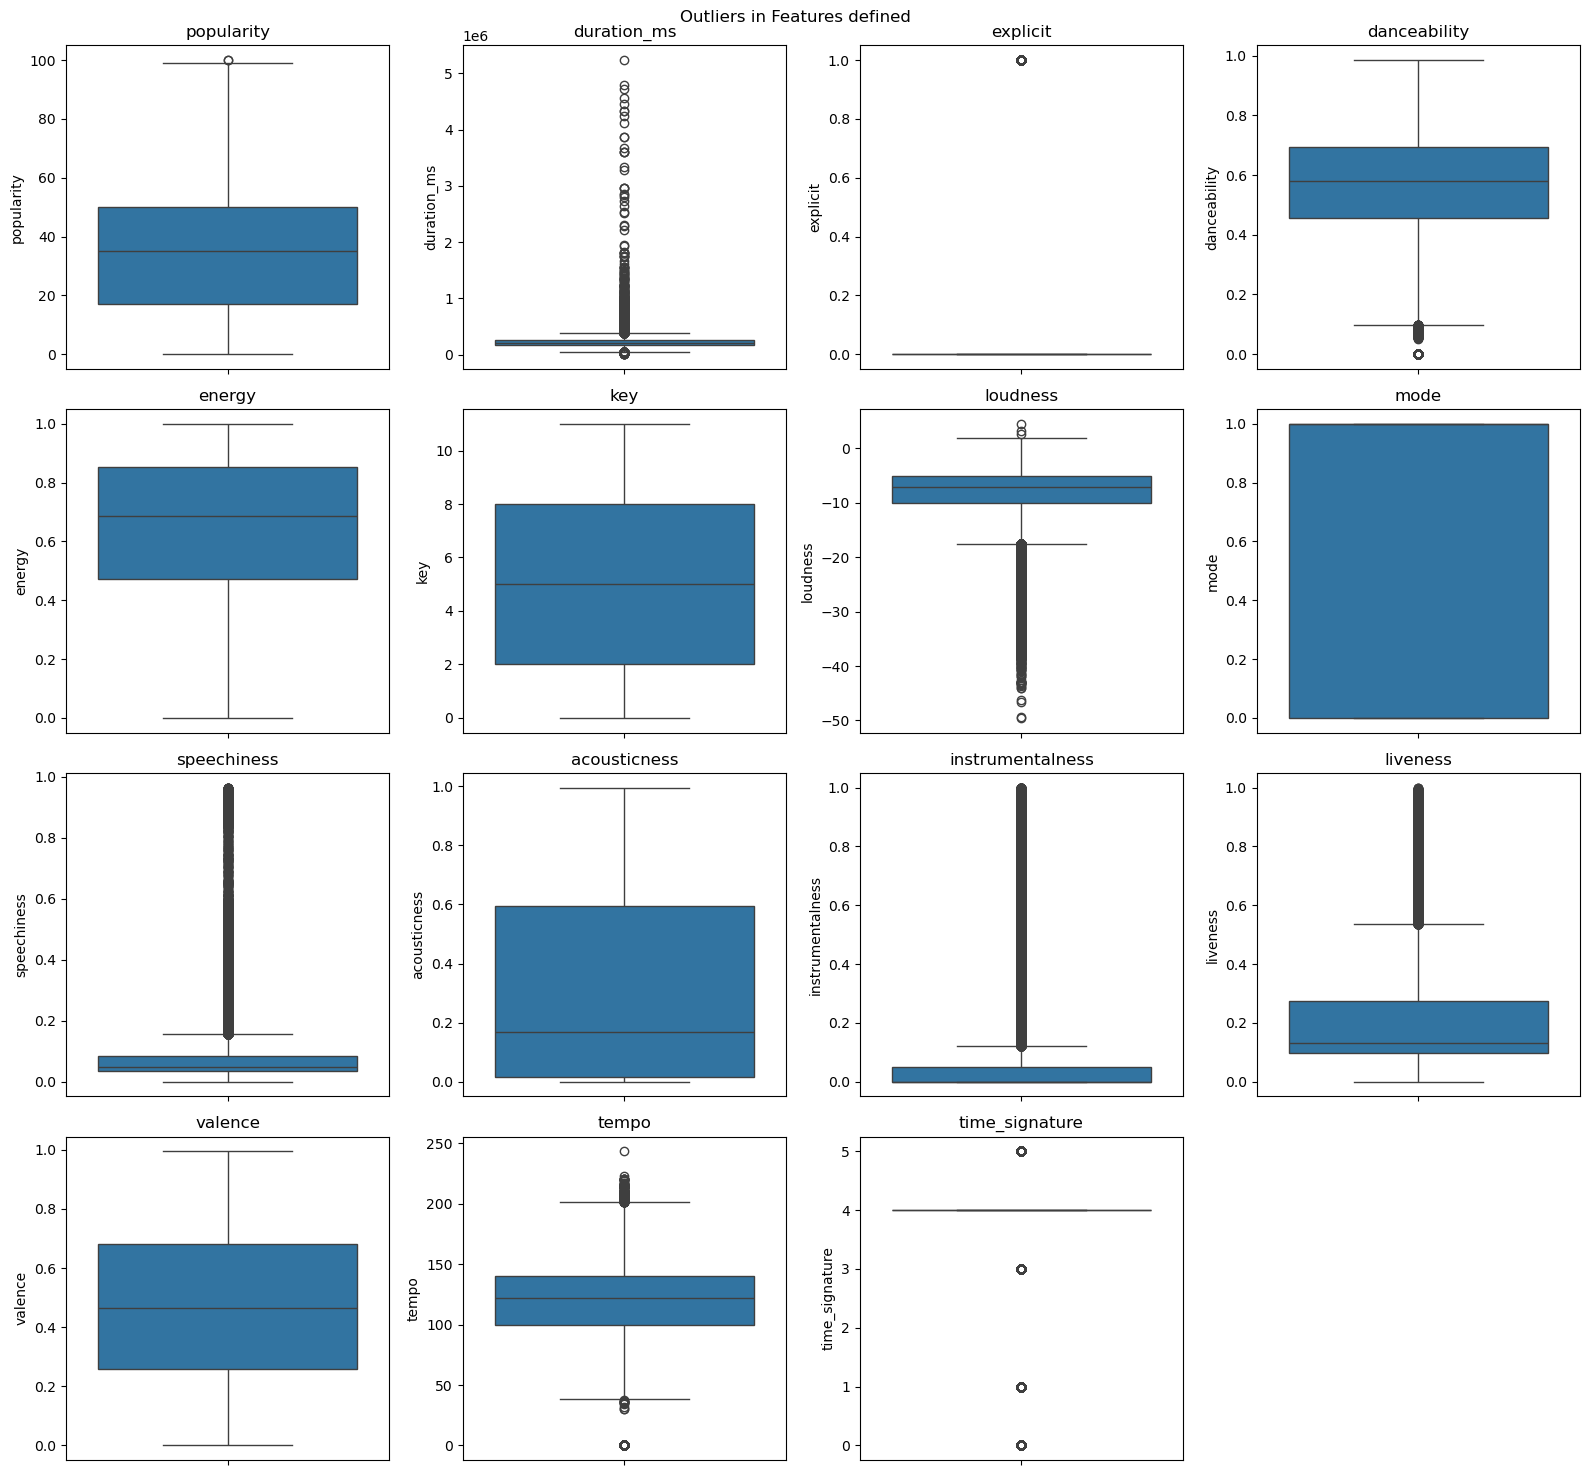

In [47]:
# Outlier Detection 
plt.figure(figsize=(16,15))
plt.suptitle("Outliers in Features defined")
for i ,col in enumerate(data.columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(data=data, y=col)
    plt.title(col)

plt.tight_layout()
plt.show()

In [48]:
pd.reset_option("display.max_rows")

In [49]:
data.shape

(113549, 15)

In [50]:
# Removing  of outliers in Features that shows unrealistic values which causes nosise
noticeable_outliers_features=['duration_ms','loudness','speechiness','tempo','time_signature']

df2=data.copy()
for col in noticeable_outliers_features:
    Q1=df2[col].quantile(0.25)
    Q3=df2[col].quantile(0.75)
    IQR=Q3-Q1

    Lowerbound=Q1-1.5*IQR
    Upperbound=Q3+1.5*IQR

    df2= df2[(df2[col]>=Lowerbound) & (df2[col]<=Upperbound)]



df2.shape

(82448, 15)

##### These columns ('duration_ms', 'loudness', 'speechiness', 'tempo', 'time_signature') contain noticeable outliers 
##### that may introduce noise or distort clustering results, so outliers will be removed from them.

<Axes: >

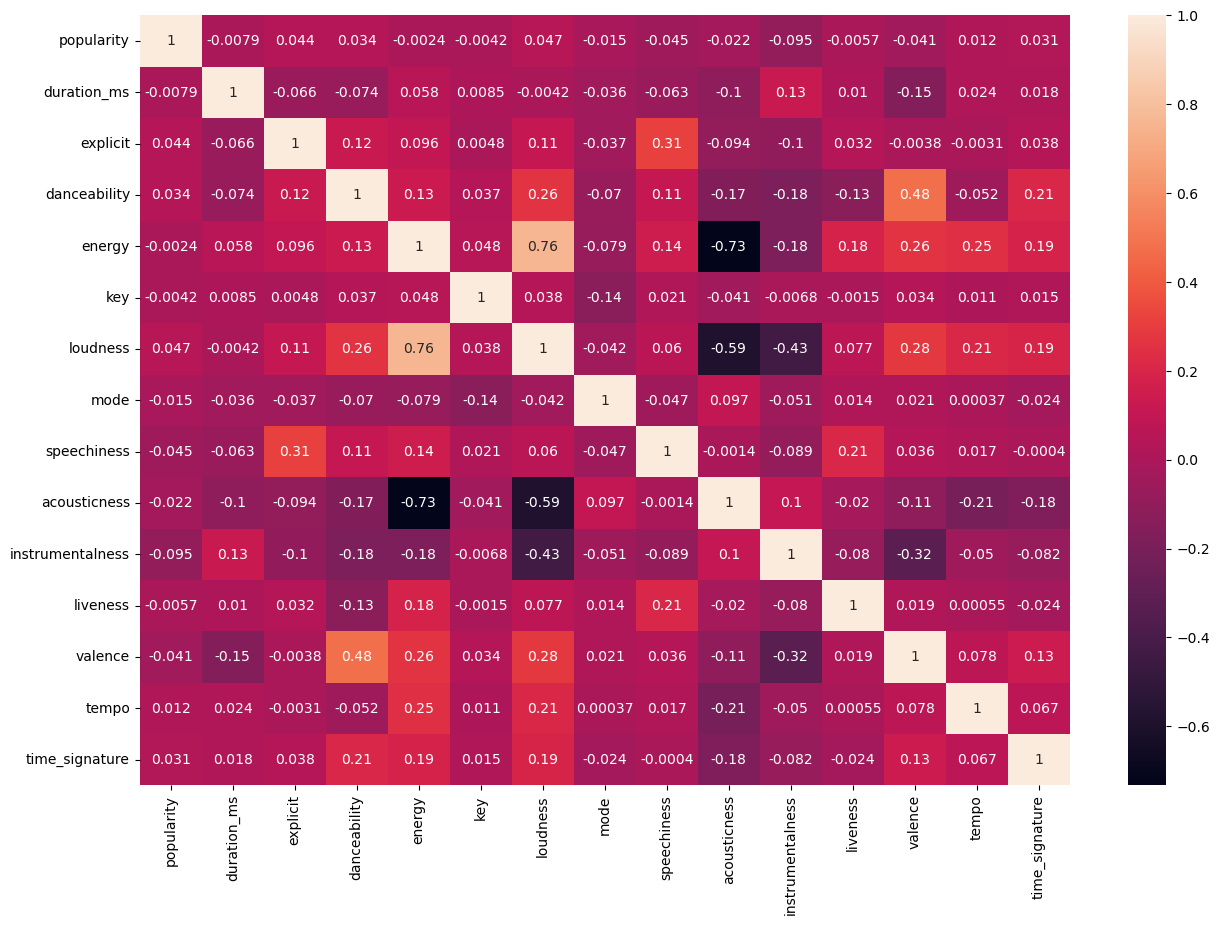

In [128]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(),annot=True)

# Feature Engineering & Model Building

In [53]:
df2.columns

Index(['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

In [54]:
# Scaling our dataset so as to have standardized values 
scaler=StandardScaler()
df_scaled=scaler.fit_transform(df2)

In [55]:
df_scaled

array([[ 1.70942626,  0.18356201, -0.27211234, ...,  0.83565573,
        -1.24403938,  0.        ],
       [ 0.91315399, -1.13983688, -0.27211234, ..., -0.94065765,
        -1.61926791,  0.        ],
       [ 1.00162868, -0.14036508, -0.27211234, ..., -1.52351048,
        -1.6609    ,  0.        ],
       ...,
       [-0.54667851,  0.84970239, -0.27211234, ...,  0.94667531,
         0.35579142,  0.        ],
       [ 0.29383111,  1.05259765, -0.27211234, ..., -0.36176981,
         0.48468177,  0.        ],
       [-0.54667851,  0.36577099, -0.27211234, ...,  0.80790083,
        -1.55777332,  0.        ]])

In [102]:
#pca reduction of the dimesions  but still keep the data importance 
Spca=PCA(n_components=2)
df_scaled_pca=Spca.fit_transform(df_scaled)

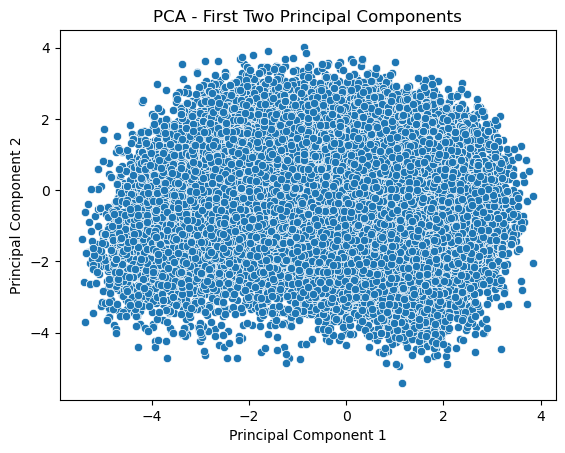

In [57]:
# Ploting the samples using 2 components after reducing the  features dimesionality using PCA
sns.scatterplot(x=df_scaled_pca[:,0], y=df_scaled_pca[:,1])
plt.title("PCA - First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [58]:
pca1=PCA()
pca_data=pca1.fit_transform(df_scaled)

In [59]:
explained_variance=np.cumsum(pca1.explained_variance_ratio_)
explained_variance


array([0.1869513 , 0.30314722, 0.39194957, 0.47369797, 0.55220203,
       0.6271379 , 0.69437131, 0.75790627, 0.81595131, 0.87329636,
       0.92452573, 0.95901187, 0.98877159, 1.        , 1.        ])

The first 10 principal components explain 92% of the total variance in the dataset. This indicates that we can reduce the dataset’s dimensionality from 15 original features to 10 components with minimal loss of information. This compressed representation retains most of the meaningful patterns and reduces noise or redundancy.

## Clustering

## Using Kmeans clustering

average silhoutte score 0.4004602189036106
average silhoutte score 0.37752901662366034
average silhoutte score 0.33994242731305385
average silhoutte score 0.34730597461318435
average silhoutte score 0.3388842984462895
average silhoutte score 0.32837120009307824
average silhoutte score 0.32197827717906463
average silhoutte score 0.3253213683039126
average silhoutte score 0.3258134793295337


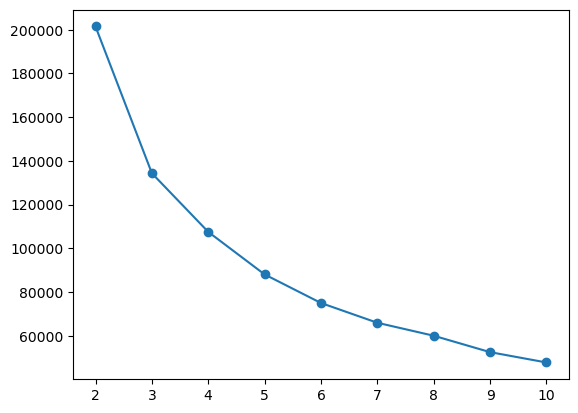

In [63]:
n_clusters=range(2,11)
inertia=[]
for i in n_clusters:
    kmean=KMeans(n_clusters=i,random_state=42)
    kmean.fit(df_scaled_pca)
    labels=kmean.labels_
    inertia.append(kmean.inertia_)

    score=silhouette_score(df_scaled_pca,labels)
    print("average silhoutte score",score)

plt.plot(n_clusters,inertia,marker='o')
    

### Choosing the Optimal Number of Clusters

Using the **silhouette scores**, we observe that **k = 2** has the highest score (0.400), followed by **k = 3** (0.378). This indicates that the samples are fairly well-grouped at these values.

When examining the **elbow curve**, we notice a sharp drop in inertia (clustering error) up to **k = 3**. After that, the improvement slows down, meaning that adding more clusters doesn't improve the results much.

Therefore, by combining both the **silhouette method** and the **elbow method**, we can say that the **optimal number of clusters is likely k = 3**, as it offers a good balance between grouping quality and simplicity.


In [64]:
# Evaluating the quality of clusters using Silhouette Score and Davies-Bouldin Index,
inertias=[]
sil_scores=[]
Davies_bouldin=[]
k_values=range(2,11)
for k in k_values:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(df_scaled_pca)
    labels=kmeans.labels_


    db_score=davies_bouldin_score(df_scaled_pca,labels)
    Davies_bouldin.append(db_score)
    
    sil_scores_a=silhouette_score(df_scaled_pca,labels)
    sil_scores.append(sil_scores_a)

    inertias_a=kmeans.inertia_
    inertias.append(inertias_a)

    

    print(f"K={k}: Davies_bouldin_score{Davies_bouldin[-1]:.2f},Silhoute Score ={sil_scores[-1]:.2f},Inertia={inertias[-1]:.2f}") ## [-1] always gives you the most recently added score.

K=2: Davies_bouldin_score1.00,Silhoute Score =0.40,Inertia=201479.05
K=3: Davies_bouldin_score0.90,Silhoute Score =0.38,Inertia=134365.79
K=4: Davies_bouldin_score0.93,Silhoute Score =0.34,Inertia=107544.33
K=5: Davies_bouldin_score0.87,Silhoute Score =0.35,Inertia=88096.94
K=6: Davies_bouldin_score0.87,Silhoute Score =0.34,Inertia=75029.01
K=7: Davies_bouldin_score0.86,Silhoute Score =0.33,Inertia=65992.23
K=8: Davies_bouldin_score0.88,Silhoute Score =0.32,Inertia=60065.03
K=9: Davies_bouldin_score0.85,Silhoute Score =0.33,Inertia=52560.94
K=10: Davies_bouldin_score0.85,Silhoute Score =0.33,Inertia=47833.40


In [65]:
pd.set_option("display.max_columns",None)

In [69]:
## Applying the optimal number of K while so as to use it in our kmeans model
kmodel=KMeans(n_clusters=3,random_state=42)
kmodel.fit(df_scaled_pca)
label=kmodel.labels_
unique_labels = np.unique(label)
print("Unique cluster labels:", unique_labels)

clusters=kmodel.cluster_centers_
print(clusters)

#Finding the numbers of samples in each label (songs in each cluster)
label_counts = collections.Counter(label)
print("Cluster counts:", label_counts)

Unique cluster labels: [0 1 2]
[[ 0.66279941  0.97986196]
 [-2.12100055 -0.11636019]
 [ 1.0275083  -1.21545613]]
Cluster counts: Counter({0: 34113, 2: 25419, 1: 22916})


## Visualize clusters in 2D using PCA.

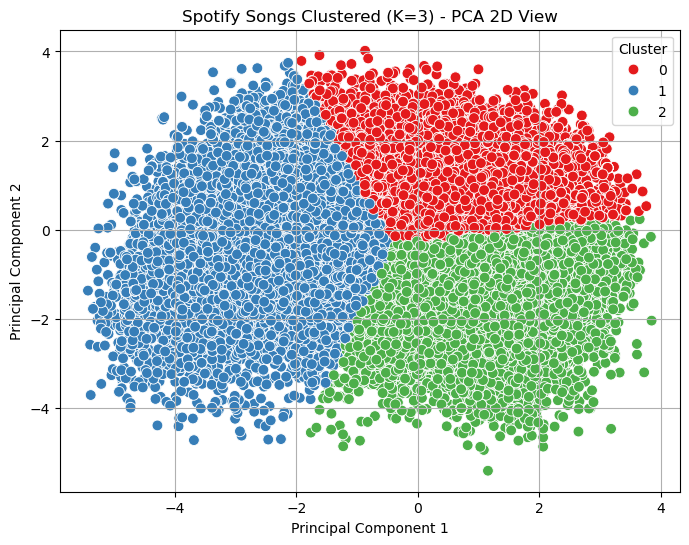

In [71]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
df_pca_2d = pca.fit_transform(df_scaled)

kmodel=KMeans(n_clusters=3,random_state=42)
kmodel.fit(df_pca_2d)
label=kmodel.labels_

# Create DataFrame with cluster labels
df_plot = pd.DataFrame(df_pca_2d, columns=['PC1', 'PC2'])
df_plot['Cluster'] = label

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=60)
plt.title("Spotify Songs Clustered (K=3) - PCA 2D View")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

This plot shows the Spotify songs clustered into **3 distinct groups** after reducing their features to 2D using PCA. The separation of points by color indicates that the clustering was successful based on the underlying song characteristics.


## Hierachial Clustering

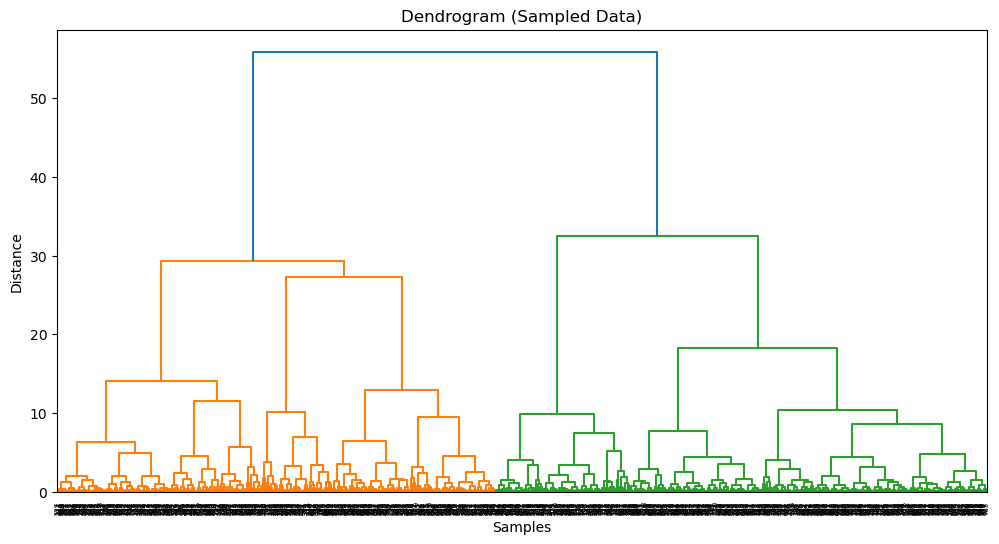

In [73]:
import numpy as np

# Randomly sample 1000 rows from the NumPy array
np.random.seed(42)
indices = np.random.choice(df_scaled_pca.shape[0], size=1000, replace=False)
sample_data = df_scaled_pca[indices]

import scipy.cluster.hierarchy as sch


# Compute linkage matrix
linkage_matrix = sch.linkage(sample_data, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
sch.dendrogram(linkage_matrix)
plt.title("Dendrogram (Sampled Data)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


In [74]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=3,linkage='ward')
hc.fit(sample_data)
label=hc.labels_
hc_unique_labels = np.unique(label)
print("Unique cluster labels:", hc_unique_labels)

Unique cluster labels: [0 1 2]


In [75]:
silhouette_agg=silhouette_score(sample_data,label)
davies_bouldin_index_agg=davies_bouldin_score(sample_data,label)
print(f"silhoutte_score={silhouette_agg:.2f}")
print(f"davies_bouldin_score={davies_bouldin_index_agg:.2f}")

silhoutte_score=0.30
davies_bouldin_score=0.91


In [79]:
seeds = [10, 42, 50, 77 ]

# Store scores for comparison  results:
results = []

for seed in seeds:
    kmeans = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(df_scaled_pca)  # use scaled data, not PCA
    
    sil_score = silhouette_score(df_scaled_pca, labels)
    db_score = davies_bouldin_score(df_scaled_pca, labels)
    
    results.append((seed, sil_score, db_score))
    print(f"Seed={seed} → Sil_Score = {sil_score:.3f}, Davies-Bouldin= {db_score:.3f}")

Seed=10 → Sil_Score = 0.377, Davies-Bouldin= 0.900
Seed=42 → Sil_Score = 0.377, Davies-Bouldin= 0.899
Seed=50 → Sil_Score = 0.377, Davies-Bouldin= 0.900
Seed=77 → Sil_Score = 0.377, Davies-Bouldin= 0.900


## Use different PCA initializations or seeds to check consistency.

In [80]:
# List of PCA component sizes 
n_components_list = [2, 3, 5, 10, 15]


for n in n_components_list:
    # Apply PCA
    pca = PCA(n_components=n)
    df_pca = pca.fit_transform(df_scaled)

    # Run KMeans on PCA-reduced data
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)

    # Compute evaluation scores
    sil = silhouette_score(df_pca, labels)
    dbi = davies_bouldin_score(df_pca, labels)

    print(f"n_components = {n} → Silhouette Score = {sil:.3f}, Davies-Bouldin Index = {dbi:.3f}")

n_components = 2 → Silhouette Score = 0.377, Davies-Bouldin Index = 0.899
n_components = 3 → Silhouette Score = 0.276, Davies-Bouldin Index = 1.252
n_components = 5 → Silhouette Score = 0.193, Davies-Bouldin Index = 1.726
n_components = 10 → Silhouette Score = 0.167, Davies-Bouldin Index = 1.913
n_components = 15 → Silhouette Score = 0.153, Davies-Bouldin Index = 2.048


## Creating a new dataset with clusters include in each sample 

In [82]:
# 1. Add original cluster labels
df2['cluster'] = kmeans.labels_

# 2. Compute mean of each feature per cluster
cluster_means = df2.groupby('cluster').mean(numeric_only=True)



In [84]:
# 3. Create new meaningful labels based on analysis
label_map = {
    0: "Chill Pop / Acoustic Groove",
    1: "Mainstream Dance / EDM-Pop",
    2: "Stripped Down / Acoustic Ballads"
}


# 4. Map the descriptive labels to a new column
df2['cluster_label'] = df2['cluster'].map(label_map)

# 5. Re-attach original non-numeric info (track name + artist)
df2 = df2.copy()
df2[['track_name', 'artists']] = df.loc[df2.index, ['track_name', 'artists']]

In [83]:
df2.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,cluster
0,73,230666,0,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,1
1,55,149610,0,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,0
2,57,210826,0,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,0
4,82,198853,0,0.618,0.443,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,0
5,58,214240,0,0.688,0.481,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.666,98.017,4,0


## Build a simple function that takes a song's features and predicts which cluster it belongs 

In [104]:
def predict_cluster(song_features, scaler, pca, model, label_map):
    
    scaled = scaler.transform([song_features])
    reduced = pca.transform(scaled)
    cluster = model.predict(reduced)[0]
    label = label_map.get(cluster, f"Unknown Cluster {cluster}")
    return cluster, label
# Sample song features (must match order and length of training features)
new_song = [0.6, 0.7, 5.0, -8.0, 1.0, 0.04, 0.2, 0.0, 0.1, 0.4, 120.0, 4.0,0.01,0.2,0.0]

# Call function
cluster_num, cluster_label = predict_cluster(new_song, scaler,Spca, kmodel,label_map)

# Print result
print(f"Cluster Number: {cluster_num}, Label: {cluster_label}")

Cluster Number: 2, Label: Stripped Down / Acoustic Ballads


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


recommendations = df2.groupby('cluster_label', group_keys=False).apply(
    lambda x: x.sample(n=min(3, len(x)), random_state=42)
)[['track_name', 'artists', 'cluster_label']]

recommendations.reset_index(drop=True, inplace=True)
recommendations

In [92]:
recommendations = df2.groupby('cluster_label', group_keys=False).apply(
    lambda x: x.sample(n=min(3, len(x)), random_state=42)
)[['track_name', 'artists', 'cluster_label']]

recommendations.reset_index(drop=True, inplace=True)
recommendations

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16920\2278649149.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recommendations = df2.groupby('cluster_label', group_keys=False).apply(


,track_name,artists,cluster_label
0,"Okh, neprijatnost'",Vladimir Nechaev,Chill Pop / Acoustic Groove
1,"Military Marches, Op. 39 ""Pomp and Circumstanc...",Edward Elgar;Royal Philharmonic Orchestra;Carl...,Chill Pop / Acoustic Groove
2,Only Love,Ben Howard,Chill Pop / Acoustic Groove
3,Koolaid - Live in Wacken 2017,Accept,Mainstream Dance / EDM-Pop
4,Whatcha Need,W&W,Mainstream Dance / EDM-Pop
5,Amigos,Juan Magán;Mariah Angeliq;Yera,Mainstream Dance / EDM-Pop
6,Talking Body - The Young Professionals Remix,Tove Lo;The Young Professionals,Stripped Down / Acoustic Ballads
7,lonewolf,convolk,Stripped Down / Acoustic Ballads
8,CÓMO SE SIENTE - Remix,Jhayco;Bad Bunny,Stripped Down / Acoustic Ballads


In [110]:
joblib.dump(scaler,'spotify_scaler.pkl')


['spotify_scaler.pkl']

In [112]:
joblib.dump(Spca,'spotify_pca.pkl')

['spotify_pca.pkl']

In [114]:
joblib.dump(kmodel,'spotify_kmean_model.pkl')

['spotify_kmean_model.pkl']